In [58]:
import numpy as np
import pandas as pd
from datetime import datetime
import lightgbm as lgb

In [31]:
df = pd.read_csv("../data/raw/train.csv",parse_dates=['date'])

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    913000 non-null  datetime64[ns]
 1   store   913000 non-null  int64         
 2   item    913000 non-null  int64         
 3   sales   913000 non-null  int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 27.9 MB


In [33]:
df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [34]:
#create time features
df['dayOfWeek'] = df['date'].dt.dayofweek
df['dayOfMonth'] = df['date'].dt.day
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year
df['isWeekend'] = df['dayOfWeek'].isin([5,6]).astype(int)

In [35]:
df.head()

,date,store,item,sales,dayOfWeek,dayOfMonth,month,year,isWeekend
0,2013-01-01,1,1,13,1,1,1,2013,0
1,2013-01-02,1,1,11,2,2,1,2013,0
2,2013-01-03,1,1,14,3,3,1,2013,0
3,2013-01-04,1,1,13,4,4,1,2013,0
4,2013-01-05,1,1,10,5,5,1,2013,1


In [36]:
## create lag feature
df['lag_1'] = df.groupby(['store','item'])['sales'].shift(1)
df['lag_7'] = df.groupby(['store','item'])['sales'].shift(7)
df['lag_14'] = df.groupby(['store','item'])['sales'].shift(14)
df['lag_30'] = df.groupby(['store','item'])['sales'].shift(30)
df['lag_365'] = df.groupby(['store','item'])['sales'].shift(365)

In [37]:
df.head(20)

,date,store,item,sales,dayOfWeek,dayOfMonth,month,year,isWeekend,lag_1,lag_7,lag_14,lag_30,lag_365
0,2013-01-01,1,1,13,1,1,1,2013,0,NaN,NaN,NaN,NaN,NaN
1,2013-01-02,1,1,11,2,2,1,2013,0,13.0,NaN,NaN,NaN,NaN
2,2013-01-03,1,1,14,3,3,1,2013,0,11.0,NaN,NaN,NaN,NaN
3,2013-01-04,1,1,13,4,4,1,2013,0,14.0,NaN,NaN,NaN,NaN
4,2013-01-05,1,1,10,5,5,1,2013,1,13.0,NaN,NaN,NaN,NaN
5,2013-01-06,1,1,12,6,6,1,2013,1,10.0,NaN,NaN,NaN,NaN
6,2013-01-07,1,1,10,0,7,1,2013,0,12.0,NaN,NaN,NaN,NaN
7,2013-01-08,1,1,9,1,8,1,2013,0,10.0,13.0,NaN,NaN,NaN
8,2013-01-09,1,1,12,2,9,1,2013,0,9.0,11.0,NaN,NaN,NaN
9,2013-01-10,1,1,9,3,10,1,2013,0,12.0,14.0,NaN,NaN,NaN


In [38]:
#create rolling mean feature
df['rolling_mean_7'] = df.groupby(['store','item'])['sales'].shift(1).rolling(7).mean()
df['rolling_mean_14'] = df.groupby(['store','item'])['sales'].shift(1).rolling(14).mean()
df['rolling_mean_30'] = df.groupby(['store','item'])['sales'].shift(1).rolling(30).mean()

In [39]:
df.head(20)

,date,store,item,sales,dayOfWeek,dayOfMonth,month,year,isWeekend,lag_1,lag_7,lag_14,lag_30,lag_365,rolling_mean_7,rolling_mean_14,rolling_mean_30
0,2013-01-01,1,1,13,1,1,1,2013,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2013-01-02,1,1,11,2,2,1,2013,0,13.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2013-01-03,1,1,14,3,3,1,2013,0,11.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2013-01-04,1,1,13,4,4,1,2013,0,14.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2013-01-05,1,1,10,5,5,1,2013,1,13.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2013-01-06,1,1,12,6,6,1,2013,1,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2013-01-07,1,1,10,0,7,1,2013,0,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2013-01-08,1,1,9,1,8,1,2013,0,10.0,13.0,NaN,NaN,NaN,11.857143,NaN,NaN
8,2013-01-09,1,1,12,2,9,1,2013,0,9.0,11.0,NaN,NaN,NaN,11.285714,NaN,NaN
9,2013-01-10,1,1,9,3,10,1,2013,0,12.0,14.0,NaN,NaN,NaN,11.428571,NaN,NaN


In [40]:
#create rolling std featuer
df['rolling_std_7'] = df.groupby(['store','item'])['sales'].shift(1).rolling(7).std()

In [41]:
df.head(20)

,date,store,item,sales,dayOfWeek,dayOfMonth,month,year,isWeekend,lag_1,lag_7,lag_14,lag_30,lag_365,rolling_mean_7,rolling_mean_14,rolling_mean_30,rolling_std_7
0,2013-01-01,1,1,13,1,1,1,2013,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2013-01-02,1,1,11,2,2,1,2013,0,13.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2013-01-03,1,1,14,3,3,1,2013,0,11.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2013-01-04,1,1,13,4,4,1,2013,0,14.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2013-01-05,1,1,10,5,5,1,2013,1,13.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2013-01-06,1,1,12,6,6,1,2013,1,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2013-01-07,1,1,10,0,7,1,2013,0,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2013-01-08,1,1,9,1,8,1,2013,0,10.0,13.0,NaN,NaN,NaN,11.857143,NaN,NaN,1.573592
8,2013-01-09,1,1,12,2,9,1,2013,0,9.0,11.0,NaN,NaN,NaN,11.285714,NaN,NaN,1.799471
9,2013-01-10,1,1,9,3,10,1,2013,0,12.0,14.0,NaN,NaN,NaN,11.428571,NaN,NaN,1.812654


In [52]:
df = df.dropna()

In [53]:
df.head(30)

,date,store,item,sales,dayOfWeek,dayOfMonth,month,year,isWeekend,lag_1,lag_7,lag_14,lag_30,lag_365,rolling_mean_7,rolling_mean_14,rolling_mean_30,rolling_std_7
365,2014-01-01,1,1,9,2,1,1,2014,0,15.0,6.0,18.0,8.0,13.0,13.000000,12.428571,12.400000,5.291503
366,2014-01-02,1,1,14,3,2,1,2014,0,9.0,16.0,7.0,21.0,11.0,13.428571,11.785714,12.433333,4.720775
367,2014-01-03,1,1,11,4,3,1,2014,0,14.0,18.0,13.0,6.0,14.0,13.142857,12.285714,12.200000,4.598136
368,2014-01-04,1,1,20,5,4,1,2014,1,11.0,17.0,11.0,13.0,13.0,12.142857,12.142857,12.366667,4.099942
369,2014-01-05,1,1,17,6,5,1,2014,1,20.0,14.0,9.0,15.0,10.0,12.571429,12.785714,12.600000,4.790864
370,2014-01-06,1,1,14,0,6,1,2014,0,17.0,5.0,8.0,17.0,12.0,13.000000,13.357143,12.666667,5.066228
371,2014-01-07,1,1,11,1,7,1,2014,0,14.0,15.0,17.0,17.0,10.0,14.285714,13.785714,12.566667,3.638419
372,2014-01-08,1,1,12,2,8,1,2014,0,11.0,9.0,6.0,8.0,9.0,13.714286,13.357143,12.366667,3.817254
373,2014-01-09,1,1,17,3,9,1,2014,0,12.0,14.0,16.0,14.0,12.0,14.142857,13.785714,12.500000,3.338092
374,2014-01-10,1,1,12,4,10,1,2014,0,17.0,11.0,18.0,7.0,9.0,14.571429,13.857143,12.600000,3.505098


In [59]:
##train baseline model



X = df.drop(['date','sales'],axis=1)
y = df['sales']

model = lgb.LGBMRegressor()

model.fit(X,y)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006773 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2086
[LightGBM] [Info] Number of data points in the train set: 730500, number of used features: 16
[LightGBM] [Info] Start training from score 54.432949


LGBMRegressor()

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

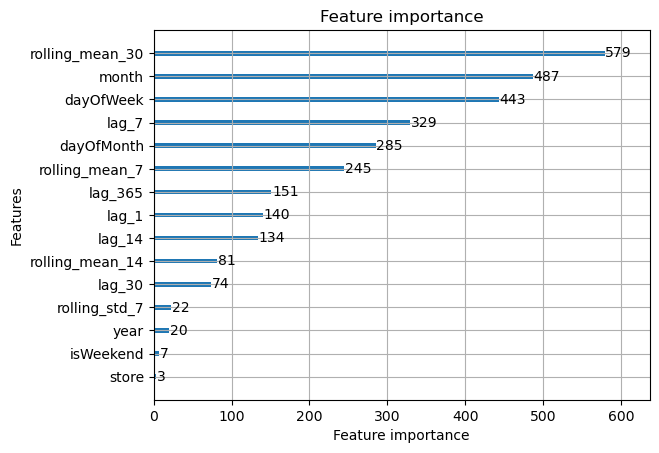

In [60]:
lgb.plot_importance(model)